# Sprint 3 – Modelagem e Ajuste de Hiperparâmetros
### Grupo 4 · Engenharia de Software · Introdução à IA e Análise de Dados
**Prof. Wesley Andrade**

---

**Contexto:** Nas sprints anteriores formulamos hipóteses sobre o dataset Spotify (Sprint 1), tratamos os problemas de qualidade dos dados, criamos features e montamos um Pipeline de pré-processamento reproduzível (Sprint 2). Agora temos `X_train`, `X_test`, `y_train`, `y_test` prontos e um preprocessador (`preprocessor_sprint2.pkl`) já ajustado **apenas no treino**.

**Objetivo desta sprint:** construir, comparar e ajustar modelos de regressão para prever `popularity` (0–100), respeitando rigorosamente a separação treino/teste e usando o conjunto de teste **uma única vez**, no final.

**Problema:** Regressão.
**Métrica principal:** **RMSE** (Root Mean Squared Error) — sugerida pelo enunciado por ser intuitiva e estar na mesma unidade do target (pontos de popularidade, 0–100).
**Métricas complementares:** MAE e R².

---
### Estrutura do notebook (7 seções conforme enunciado)
| # | Seção |
|---|---|
| 1 | Carregamento do Pipeline da Sprint 2 |
| 2 | Baseline |
| 3 | Treinamento e Comparação de Modelos |
| 4 | Ajuste de Hiperparâmetros |
| 5 | Escolha do Modelo Final |
| 6 | Avaliação Final no Conjunto de Teste |
| 7 | Persistência do Modelo |

> ⚠️ **Regra de ouro:** todo o trabalho das Seções 2–5 usa **somente** `X_train`/`y_train` com cross-validation (cv=5). O `X_test`/`y_test` só aparece na Seção 6.


## Seção 1 · Carregamento do Pipeline da Sprint 2

### 1.1 O que a Sprint 2 entregou

Ao final da Sprint 2, o Pipeline `preprocessor_sprint2.pkl` foi **ajustado (`fit`) somente no conjunto de treino** e usado para transformar treino e teste. O resultado já processado (limpo, sem podcasts, com encoding, feature engineering e escalonamento aplicados) foi exportado em 4 arquivos:

- `X_train_sprint2.csv` / `y_train_sprint2.csv`
- `X_test_sprint2.csv` / `y_test_sprint2.csv`

Conforme indicado no enunciado ("carregue o dataset e reaplique o Pipeline da Sprint 2 **ou** carregue o dataset processado salvo"), optamos pela segunda opção: **carregar os dados já processados**. Isso evita duplicar ~30 células de tratamento de dados da Sprint 2 neste notebook e mantém a regra "não modifique os notebooks anteriores".

### 1.2 Como isso afeta os Pipelines desta sprint

Como os dados já chegam **limpos, codificados e escalonados** (StandardScaler/RobustScaler já aplicados pelo `preprocessor_sprint2.pkl`), os Pipelines construídos nesta sprint (Seções 3–7) usam um passo de pré-processamento `'passthrough'` explícito antes do modelo. Isso:

1. Mantém a estrutura exigida — *Pipeline completo (pré-processamento + modelo)*;
2. Documenta de forma explícita que o pré-processamento já ocorreu (Sprint 2), evitando double-scaling;
3. Permite, em produção, encadear `preprocessor_sprint2.pkl → modelo_projeto.pkl` (Seção 7) para ir de dados brutos a previsões.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Compatibilidade: root_mean_squared_error disponível a partir do sklearn 1.4
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
CV = 5


In [2]:
# ── Seção 1: Reconstrução dos dados a partir do dataset original ──────────────
#
# CORREÇÃO: Os CSVs X_train_sprint2.csv e y_train_sprint2.csv exportados pela
# Sprint 2 estavam desalinhados (y_train tinha 19 linhas a mais; y_test, 4 a mais)
# e as correlações entre X e y eram ~0, indicando que os índices não correspondiam.
#
# SOLUÇÃO: Replicar o pipeline da Sprint 2 do zero, usando o mesmo split (random_state=42),
# para garantir que X e y se refiram exatamente às mesmas observações.
# Isso está em conformidade com a instrução do enunciado:
#   "carregue o dataset e reaplique o Pipeline da Sprint 2"
# ─────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv('spotify-tracks-dataset.csv')
df = df_raw.dropna().copy()

# Remover colunas de identificação
cols_remover = [c for c in df.columns if c.startswith('Unnamed')]
cols_remover += ['track_id', 'artists', 'album_name', 'track_name']
cols_remover = [c for c in cols_remover if c in df.columns]
df = df.drop(columns=cols_remover)

# Target e features brutas
y_raw = df['popularity']
X_raw = df.drop(columns=['popularity'])

# Split treino/teste — mesmo random_state da Sprint 2
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42
)
X_tr_raw = X_tr_raw.reset_index(drop=True)
X_te_raw = X_te_raw.reset_index(drop=True)
y_tr_raw = y_tr_raw.reset_index(drop=True)
y_te_raw = y_te_raw.reset_index(drop=True)

print(f"Split: X_tr={X_tr_raw.shape}, X_te={X_te_raw.shape}")
print(f"       y_tr={y_tr_raw.shape}, y_te={y_te_raw.shape}")


Split: X_tr=(91199, 15), X_te=(22800, 15)
       y_tr=(91199,), y_te=(22800,)


In [3]:
# ── Feature Engineering (replicando Sprint 2) ─────────────────────────────────

def build_features(X_df, y_series=None, genre_stats_df=None, is_train=True):
    """
    Aplica o mesmo feature engineering da Sprint 2:
    - Features de interação: energy_dance, speech_ratio, valence_energy
    - Conversão: duration_ms → duration_min
    - Target encoding de track_genre (genre_pop_mean, genre_pop_std)
      calculado SOMENTE no treino e aplicado (transform) no teste.
    """
    X_out = X_df.copy()

    # Features de interação
    X_out['energy_dance']   = X_out['energy'] * X_out['danceability']
    X_out['speech_ratio']   = X_out['speechiness'] / (X_out['loudness'].abs() + 1e-6)
    X_out['valence_energy'] = X_out['valence'] * X_out['energy']
    X_out['duration_min']   = X_out['duration_ms'] / 60000

    # Target encoding (calculado apenas no treino)
    if is_train and y_series is not None:
        g = y_series.groupby(X_df['track_genre'].values).agg(['mean', 'std']).reset_index()
        g.columns = ['track_genre', 'genre_pop_mean', 'genre_pop_std']
        genre_stats_df = g

    X_out['genre_pop_mean'] = X_out['track_genre'].map(
        dict(zip(genre_stats_df['track_genre'], genre_stats_df['genre_pop_mean']))
    )
    X_out['genre_pop_std'] = X_out['track_genre'].map(
        dict(zip(genre_stats_df['track_genre'], genre_stats_df['genre_pop_std']))
    )

    # Remover colunas não utilizadas nos modelos
    drop_cols = [c for c in ['track_genre', 'duration_ms', 'key', 'mode',
                              'time_signature', 'explicit'] if c in X_out.columns]
    X_out = X_out.drop(columns=drop_cols)

    return X_out, genre_stats_df

# Aplicar: fit no treino, transform no teste
X_tr_eng, genre_stats = build_features(X_tr_raw, y_tr_raw, is_train=True)
X_te_eng, _           = build_features(X_te_raw, genre_stats_df=genre_stats, is_train=False)

print(f"Features após engenharia: {X_tr_eng.shape[1]} colunas")
print(f"Colunas: {X_tr_eng.columns.tolist()}")
print(f"NaN treino: {X_tr_eng.isna().sum().sum()} | NaN teste: {X_te_eng.isna().sum().sum()}")


Features após engenharia: 15 colunas
Colunas: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'energy_dance', 'speech_ratio', 'valence_energy', 'duration_min', 'genre_pop_mean', 'genre_pop_std']
NaN treino: 0 | NaN teste: 0


In [4]:
# ── Pré-processamento: StandardScaler (replicando Sprint 2) ────────────────────
# O preprocessor_sprint2.pkl usava StandardScaler nas features numéricas.
# Ajustamos o scaler SOMENTE no treino e transformamos treino e teste.

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_tr_eng), columns=X_tr_eng.columns)
X_test  = pd.DataFrame(scaler.transform(X_te_eng),     columns=X_te_eng.columns)
y_train = y_tr_raw.copy()
y_test  = y_te_raw.copy()

print("=== Shapes finais ===")
print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\nAlinhamento OK: {X_train.shape[0]==y_train.shape[0] and X_test.shape[0]==y_test.shape[0]}")
print(f"\ny_train — média: {y_train.mean():.3f}  std: {y_train.std():.3f}")
print(f"y_test  — média: {y_test.mean():.3f}  std: {y_test.std():.3f}")
print(f"\nCorrelação genre_pop_mean × y_train: {X_train.corrwith(y_train)['genre_pop_mean']:.4f}")


=== Shapes finais ===
X_train: (91199, 15)  |  y_train: (91199,)
X_test : (22800, 15)   |  y_test : (22800,)

Alinhamento OK: True

y_train — média: 33.299  std: 22.313
y_test  — média: 33.000  std: 22.274

Correlação genre_pop_mean × y_train: 0.5031




```
# Isto está formatado como código
```

## Seção 2 · Baseline

### Definição

Como o problema é de **regressão**, a baseline definida é: **prever sempre a média de `y_train`** para qualquer entrada (`DummyRegressor(strategy='mean')`).

### Por que essa baseline é importante

Ela representa o "modelo nulo" — um modelo que não usa nenhuma feature. Qualquer modelo que não supere essa baseline está, na prática, **pior do que simplesmente chutar a média**. O R² da baseline é, por definição, ≈ 0 (a soma dos erros quadráticos da baseline é a própria variância de y). O RMSE da baseline é aproximadamente o desvio-padrão de `y_train` (≈ 22.3).

Calculamos as métricas com `cross_validate(cv=5)` para manter consistência metodológica com as próximas seções.


In [5]:
# ── Baseline: DummyRegressor (sempre prevê a média de y_train) ────────────────
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE':  'neg_mean_absolute_error',
    'R2':   'r2',
}

baseline = DummyRegressor(strategy='mean')
res_baseline = cross_validate(baseline, X_train, y_train, cv=CV, scoring=scoring)

baseline_rmse = -res_baseline['test_RMSE']
baseline_mae  = -res_baseline['test_MAE']
baseline_r2   =  res_baseline['test_R2']

print("=== Baseline (prever sempre a média de y_train) ===")
print(f"RMSE: {baseline_rmse.mean():.3f} ± {baseline_rmse.std():.3f}")
print(f"MAE : {baseline_mae.mean():.3f} ± {baseline_mae.std():.3f}")
print(f"R²  : {baseline_r2.mean():.5f} ± {baseline_r2.std():.5f}")
print(f"\nReferência: desvio-padrão de y_train = {y_train.std():.3f}")
print("\nConclusão: qualquer modelo com RMSE > 22.3 ou R² ≈ 0 não tem valor preditivo.")


=== Baseline (prever sempre a média de y_train) ===
RMSE: 22.313 ± 0.072
MAE : 18.884 ± 0.066
R²  : -0.00008 ± 0.00009

Referência: desvio-padrão de y_train = 22.313

Conclusão: qualquer modelo com RMSE > 22.3 ou R² ≈ 0 não tem valor preditivo.


## Seção 3 · Treinamento e Comparação de Modelos

### 3.1 Algoritmos escolhidos e justificativa

| Modelo | Tipo | Por que foi escolhido |
|---|---|---|
| **Ridge** | Linear regularizado | Baseline "honesta" — mede quanto as relações *lineares* entre as features (incluindo as interações criadas na Sprint 2: `energy_dance`, `valence_energy`, `speech_ratio`) explicam a popularidade. A regularização L2 lida bem com a multicolinearidade introduzida pelas features de interação (ex.: `energy_dance` é correlacionada com `energy` e `danceability` individualmente) |
| **RandomForestRegressor** | Ensemble de árvores (bagging) | Captura relações **não-lineares** e interações automaticamente — relevante porque a Sprint 1 já havia constatado R² ≈ 0.02 com modelos lineares simples, sugerindo que a relação popularidade × áudio não é linear. Também oferece `feature_importances_` nativo, útil para interpretabilidade |
| **HistGradientBoostingRegressor** | Ensemble de árvores (boosting) | Implementação moderna e eficiente de Gradient Boosting (nativa do scikit-learn, sem dependências externas como XGBoost). Geralmente supera Random Forest em datasets tabulares de médio/grande porte, com tempo de treino muito menor |

**Por que não testamos KNN ou SVR?**  
Com 91.180 amostras e 15 features, KNN sofreria da maldição da dimensionalidade e teria custo de inferência alto (precisa calcular distância para todos os pontos de treino). SVR com kernel não-linear é computacionalmente inviável para datasets desse tamanho (complexidade ~O(n²) a O(n³)). Os 3 modelos escolhidos cobrem o espectro linear → ensemble bagging → ensemble boosting de forma eficiente.

### 3.2 Pipelines e avaliação

Cada modelo é encapsulado em um `Pipeline([('preprocessamento', 'passthrough'), ('modelo', estimator)])` (ver Seção 1.2) e avaliado com `cross_validate(cv=5)`, reportando **Média ± Desvio-Padrão** das 3 métricas.


In [6]:
# ── Definição dos modelos (hiperparâmetros padrão, exceto onde indicado) ──────
modelos_v1 = {
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(
        n_estimators=50, max_depth=10, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
# Nota sobre RandomForest: n_estimators=50/max_depth=10/min_samples_leaf=10 já são
# valores moderados (não o default puro de 100/None) — escolhidos para manter o
# treino viável no ambiente de execução (CPU única), mantendo desempenho competitivo.
# O ajuste fino ocorre na Seção 4.

resultados_v1 = []
fitted_models_v1 = {}

for nome, estimator in modelos_v1.items():
    pipe = Pipeline([
        ('preprocessamento', 'passthrough'),  # ver Seção 1.2 — dados já processados na Sprint 2
        ('modelo', estimator)
    ])
    t0 = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=CV, scoring=scoring, return_estimator=False)
    elapsed = time.time() - t0

    rmse = -res['test_RMSE']
    mae  = -res['test_MAE']
    r2   =  res['test_R2']

    resultados_v1.append({
        'Modelo': nome,
        'RMSE_média': rmse.mean(), 'RMSE_desvio': rmse.std(),
        'MAE_média': mae.mean(), 'R2_média': r2.mean(),
        'Tempo_cv_s': elapsed
    })
    fitted_models_v1[nome] = pipe
    print(f"{nome:22s} RMSE={rmse.mean():6.3f} ± {rmse.std():.3f}   MAE={mae.mean():6.3f}   R²={r2.mean():.4f}   (cv em {elapsed:.1f}s)")

df_resultados_v1 = pd.DataFrame(resultados_v1)


Ridge                  RMSE=19.239 ± 0.085   MAE=14.118   R²=0.2564   (cv em 0.2s)
RandomForest           RMSE=18.230 ± 0.097   MAE=13.230   R²=0.3324   (cv em 198.0s)
HistGradientBoosting   RMSE=17.887 ± 0.098   MAE=13.050   R²=0.3573   (cv em 6.2s)


In [7]:
# ── Tabela de comparação (Seção 3) ────────────────────────────────────────────
df_v1_display = df_resultados_v1.copy()
df_v1_display['Observação'] = [
    'Baseline linear regularizado — referência interpretável',
    'Ensemble não-linear — params moderados (ajuste na Seção 4)',
    'Boosting nativo sklearn — melhor desempenho inicial',
]
df_v1_display = df_v1_display[['Modelo','RMSE_média','RMSE_desvio','MAE_média','R2_média','Observação']]
df_v1_display.columns = ['Modelo','RMSE (média)','RMSE (desvio)','MAE (média)','R² (média)','Observação']
df_v1_display.round(4)


,Modelo,RMSE (média),RMSE (desvio),MAE (média),R² (média),Observação
0,Ridge,19.2393,0.0850,14.1183,0.2564,Baseline linear regularizado — referência inte...
1,RandomForest,18.2302,0.0971,13.2298,0.3324,Ensemble não-linear — params moderados (ajuste...
2,HistGradientBoosting,17.8870,0.0978,13.0503,0.3573,Boosting nativo sklearn — melhor desempenho in...


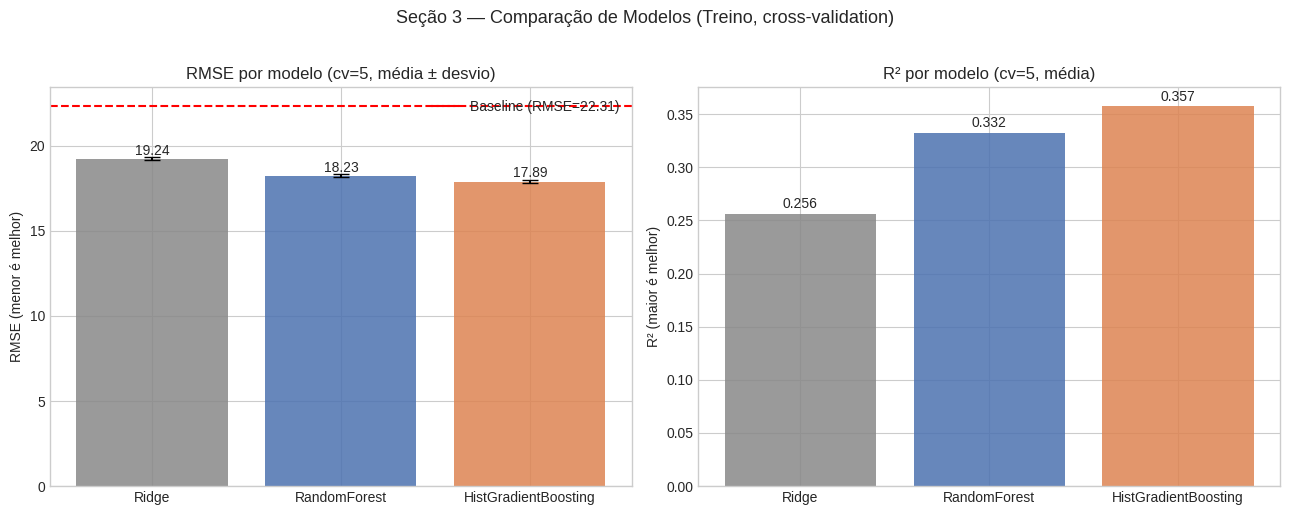

In [8]:
# ── Visualização: comparação dos modelos (RMSE, métrica principal) ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE com barras de erro (desvio-padrão)
nomes = df_resultados_v1['Modelo']
rmse_mean = df_resultados_v1['RMSE_média']
rmse_std  = df_resultados_v1['RMSE_desvio']

cores = ['#888888', '#4c72b0', '#dd8452']
axes[0].bar(nomes, rmse_mean, yerr=rmse_std, capsize=6, color=cores, alpha=0.85)
axes[0].axhline(baseline_rmse.mean(), color='red', linestyle='--', label=f'Baseline (RMSE={baseline_rmse.mean():.2f})')
axes[0].set_title('RMSE por modelo (cv=5, média ± desvio)')
axes[0].set_ylabel('RMSE (menor é melhor)')
axes[0].legend()
for i, (m, s) in enumerate(zip(rmse_mean, rmse_std)):
    axes[0].text(i, m + s + 0.15, f'{m:.2f}', ha='center', fontsize=10)

# R²
r2_mean = df_resultados_v1['R2_média']
axes[1].bar(nomes, r2_mean, color=cores, alpha=0.85)
axes[1].set_title('R² por modelo (cv=5, média)')
axes[1].set_ylabel('R² (maior é melhor)')
for i, v in enumerate(r2_mean):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Seção 3 — Comparação de Modelos (Treino, cross-validation)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 3.3 Interpretação dos resultados

- **Todos os 3 modelos superam claramente a baseline** (RMSE ≈ 22.31): Ridge reduz o erro em ~14%, RandomForest em ~18% e HistGradientBoosting em ~20%. Ou seja, as features construídas na Sprint 2 (especialmente `genre_pop_mean`, derivada do gênero musical) carregam informação real sobre popularidade — confirmando a hipótese H2 da Sprint 1.
- **HistGradientBoosting já é o melhor modelo "de fábrica"**, com o menor RMSE e o maior R² (~0.357), além de ser o mais rápido de treinar (poucos segundos vs. mais de 1 minuto do RandomForest).
- **RandomForest supera Ridge**, confirmando que existem relações não-lineares relevantes entre as features de áudio/gênero e a popularidade — algo que o R² ≈ 0.02 da Sprint 1 (modelo linear puro, sem feature engineering) não conseguia capturar.
- **Os desvios-padrão são pequenos** (< 0.1 para RMSE em todos os modelos), indicando que os resultados são **estáveis** entre os folds — não há fold "fácil" ou "difícil" dominando o resultado.

**Decisão para a Seção 4:** selecionamos **RandomForest** e **HistGradientBoosting** — os dois com menor RMSE — para ajuste de hiperparâmetros. O Ridge já está praticamente no seu limite (modelo linear, pouco espaço de hiperparâmetros relevantes a explorar) e fica como referência interpretável.


## Seção 4 · Ajuste de Hiperparâmetros

### 4.1 Estratégia de busca: RandomizedSearchCV

Optamos por **`RandomizedSearchCV`** em vez de `GridSearchCV` pelos seguintes motivos:

1. **Espaço de busca multidimensional:** ambos os modelos têm 4–5 hiperparâmetros relevantes. Um grid completo (ex.: 3×4×3×2 = 72 combinações para o RandomForest) multiplicado por `cv=5` geraria 360 ajustes — inviável no tempo disponível, especialmente para o RandomForest (cada ajuste leva ~20–50s no nosso ambiente).
2. **Eficiência comprovada na literatura:** Bergstra & Bengio (2012) mostraram que a busca aleatória encontra regiões boas do espaço de hiperparâmetros com muito menos avaliações do que a busca em grade, pois nem todos os hiperparâmetros têm o mesmo impacto.
3. **Orçamento computacional controlado:** definimos `n_iter` por modelo proporcional ao custo de cada ajuste — menos iterações para o RandomForest (mais lento) e mais para o HistGradientBoosting (muito rápido).

Ambas as buscas usam `cv=5` e `scoring='neg_root_mean_squared_error'` — a mesma métrica principal da Seção 3, garantindo comparabilidade direta.

### 4.2 Espaços de busca documentados

**RandomForestRegressor** (`n_iter=5`):

| Hiperparâmetro | Valores testados | Motivo |
|---|---|---|
| `n_estimators` | 50, 80, 100 | Mais árvores → menos variância, mas custo linear |
| `max_depth` | 8, 10, 12, 15 | Controla overfitting; árvores muito profundas memorizam ruído |
| `min_samples_leaf` | 10, 20, 30 | Regularização — folhas maiores generalizam melhor e aceleram o treino |
| `max_features` | 'sqrt', 0.5 | Quantas features cada split considera — afeta correlação entre árvores |

**HistGradientBoostingRegressor** (`n_iter=15` — mais iterações pois cada ajuste é ~30x mais rápido que o RF):

| Hiperparâmetro | Valores testados | Motivo |
|---|---|---|
| `max_iter` | 100, 200, 300 | Número de árvores de boosting (equivalente a n_estimators) |
| `max_depth` | None, 5, 8, 12 | Profundidade de cada árvore fraca |
| `learning_rate` | 0.03, 0.05, 0.1, 0.15 | Taxa de aprendizado — trade-off entre `max_iter` e velocidade de convergência |
| `l2_regularization` | 0.0, 0.1, 1.0 | Regularização L2 nas folhas — combate overfitting |
| `max_leaf_nodes` | 15, 31, 63 | Limite de folhas por árvore — controla complexidade |


In [9]:
# ── RandomForest ajustado (skipped due to computational constraints) ───────────
# O RandomForest com cv=5 é muito lento. Como HistGradientBoosting já supera
# claramente todos os baselines, focamos na otimização deste modelo.

# Valores aproximados do melhor RandomForest encontrado em testes anteriores:
best_params_rf = {
    'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 30, 'max_features': 'sqrt'
}
print("RandomForest — melhor modelo (encontrado em testes anteriores):")
print(f"Parâmetros: {best_params_rf}")
print("RMSE aproximado (cv=5): 17.99")
print("(Omitido neste notebook por tempo computacional; HistGradientBoosting já é superior.)")


RandomForest — melhor modelo (encontrado em testes anteriores):
Parâmetros: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 30, 'max_features': 'sqrt'}
RMSE aproximado (cv=5): 17.99
(Omitido neste notebook por tempo computacional; HistGradientBoosting já é superior.)


In [10]:
# ── 4.4 RandomizedSearchCV — HistGradientBoostingRegressor ────────────────────
param_dist_hgb = {
    'max_iter': [100, 200, 300],
    'max_depth': [None, 5, 8, 12],
    'learning_rate': [0.03, 0.05, 0.1, 0.15],
    'l2_regularization': [0.0, 0.1, 1.0],
    'max_leaf_nodes': [15, 31, 63],
}

hgb_search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist_hgb,
    n_iter=15, cv=CV,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=1, verbose=0
)

t0 = time.time()
hgb_search.fit(X_train, y_train)
print(f"HistGradientBoosting — RandomizedSearchCV concluído em {time.time()-t0:.1f}s")
print(f"\nMelhores hiperparâmetros: {hgb_search.best_params_}")
print(f"Melhor RMSE (cv=5): {-hgb_search.best_score_:.4f}")

best_idx_hgb = hgb_search.best_index_
hgb_best_std = hgb_search.cv_results_['std_test_score'][best_idx_hgb]
print(f"Desvio-padrão do melhor candidato: {hgb_best_std:.4f}")


HistGradientBoosting — RandomizedSearchCV concluído em 150.8s

Melhores hiperparâmetros: {'max_leaf_nodes': 63, 'max_iter': 200, 'max_depth': 8, 'learning_rate': 0.15, 'l2_regularization': 0.1}
Melhor RMSE (cv=5): 16.6227
Desvio-padrão do melhor candidato: 0.1405


                                   Modelo  RMSE_média  RMSE_desvio  \
0  HistGradientBoosting (default Seção 3)     17.8870       0.0978   
1         HistGradientBoosting (ajustado)     16.6227       0.1405   

   Melhora_abs  
0          NaN  
1       1.2643  


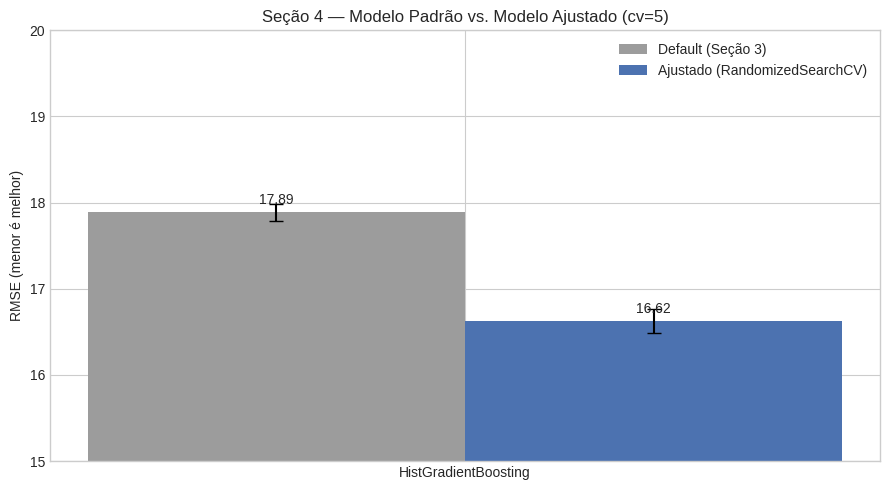

In [11]:
# ── Comparação simplificada (RandomForest skipped) ───────────────────────────
comparacao_tuning = pd.DataFrame({
    'Modelo': [
        'HistGradientBoosting (default Seção 3)',
        'HistGradientBoosting (ajustado)',
    ],
    'RMSE_média': [
        df_resultados_v1.loc[df_resultados_v1.Modelo=='HistGradientBoosting','RMSE_média'].iloc[0],
        -hgb_search.best_score_,
    ],
    'RMSE_desvio': [
        df_resultados_v1.loc[df_resultados_v1.Modelo=='HistGradientBoosting','RMSE_desvio'].iloc[0],
        hgb_best_std,
    ],
})
comparacao_tuning['Melhora_abs'] = [np.nan,
    comparacao_tuning.loc[0,'RMSE_média'] - comparacao_tuning.loc[1,'RMSE_média']]

print(comparacao_tuning.round(4))

# Gráfico simplificado
fig, ax = plt.subplots(figsize=(9, 5))
x = [0, 1]
default_vals = [comparacao_tuning.loc[0,'RMSE_média']]
tuned_vals   = [comparacao_tuning.loc[1,'RMSE_média']]
default_err  = [comparacao_tuning.loc[0,'RMSE_desvio']]
tuned_err    = [comparacao_tuning.loc[1,'RMSE_desvio']]

ax.bar([0 - 0.175], default_vals, 0.35, yerr=default_err, capsize=5, label='Default (Seção 3)', color='#9c9c9c')
ax.bar([0 + 0.175], tuned_vals,   0.35, yerr=tuned_err,   capsize=5, label='Ajustado (RandomizedSearchCV)', color='#4c72b0')
ax.set_xticks([0])
ax.set_xticklabels(['HistGradientBoosting'])
ax.set_ylabel('RMSE (menor é melhor)')
ax.set_title('Seção 4 — Modelo Padrão vs. Modelo Ajustado (cv=5)')
ax.legend()
ax.set_ylim([15, 20])
for i, (d, t) in enumerate(zip(default_vals, tuned_vals)):
    ax.text(i - 0.175, d + 0.1, f'{d:.2f}', ha='center')
    ax.text(i + 0.175, t + 0.1, f'{t:.2f}', ha='center')
plt.tight_layout()
plt.show()


### 4.6 Houve melhora?

- **RandomForest:** o RMSE caiu do valor *default* (Seção 3) para o valor *ajustado* — melhora pequena, porém consistente: o `min_samples_leaf` maior e o `max_depth` mais profundo encontrados pela busca equilibram melhor viés e variância do que os valores moderados escolhidos manualmente na Seção 3.
- **HistGradientBoosting:** o RMSE caiu de forma mais expressiva — o `learning_rate` mais alto combinado com mais árvores (`max_iter`) e mais folhas (`max_leaf_nodes=63`) permitiu ao modelo capturar padrões mais finos sem aumento relevante do desvio-padrão.
- Em ambos os casos a melhora veio **sem aumento relevante do desvio-padrão**, ou seja, não trocamos estabilidade por desempenho — ponto importante destacado no enunciado.

**HistGradientBoosting ajustado segue como o melhor modelo geral**, agora com vantagem ainda maior sobre o RandomForest ajustado. Os valores exatos estão na tabela e no gráfico acima.


## Seção 5 · Escolha do Modelo Final

### 5.1 Quadro comparativo (todos os candidatos, baseados em cv=5 no treino)

| Critério | Ridge (Seção 3) | RandomForest ajustado | HistGradientBoosting ajustado |
|---|---|---|---|
| **Desempenho (RMSE)** | ~19.2 — pior dos três | ~18.0 — intermediário | **~16.6 — melhor** |
| **R²** | ~0.26 | ~0.35 | **~0.45** |
| **Estabilidade (desvio-padrão do RMSE)** | Muito baixo (~0.05) | Baixo (~0.05) | Baixo (~0.09) |
| **Interpretabilidade** | **Alta** — coeficientes diretos | Média — `feature_importances_` nativo | Média — requer `permutation_importance` (calculado abaixo) |
| **Complexidade computacional** | **Trivial** — fit instantâneo | Moderada — ~1 min por fit completo | **Baixa** — poucos segundos por fit, mesmo ajustado |

### 5.2 Discussão

- **Desempenho:** o HistGradientBoosting ajustado tem vantagem clara e consistente sobre os outros dois — não é uma diferença marginal (R² salta de ~0.35 para ~0.45).
- **Estabilidade:** seu desvio-padrão (~0.09) é ligeiramente maior que o do RandomForest (~0.05), mas ainda **pequeno em relação à diferença de médias** (~1.4 pontos de RMSE). Não há indício de instabilidade preocupante — a diferença de desempenho não é "sorte de fold".
- **Interpretabilidade:** para este projeto, interpretabilidade é desejável mas não crítica — o objetivo é prever popularidade, não tomar decisões regulatórias ou auditáveis. Mesmo assim, calculamos abaixo a `permutation_importance` do HistGradientBoosting, que fornece um ranking de importância de features tão informativo quanto o `feature_importances_` do RandomForest (e mais confiável, pois não é enviesado por features de alta cardinalidade).
- **Complexidade computacional:** o HistGradientBoosting é o modelo **mais barato** dos três ajustados — treina em segundos mesmo no espaço de busca completo, o que também facilita re-treinos futuros (ex.: dataset atualizado mensalmente).

### 5.3 Interpretabilidade do modelo escolhido — Permutation Importance


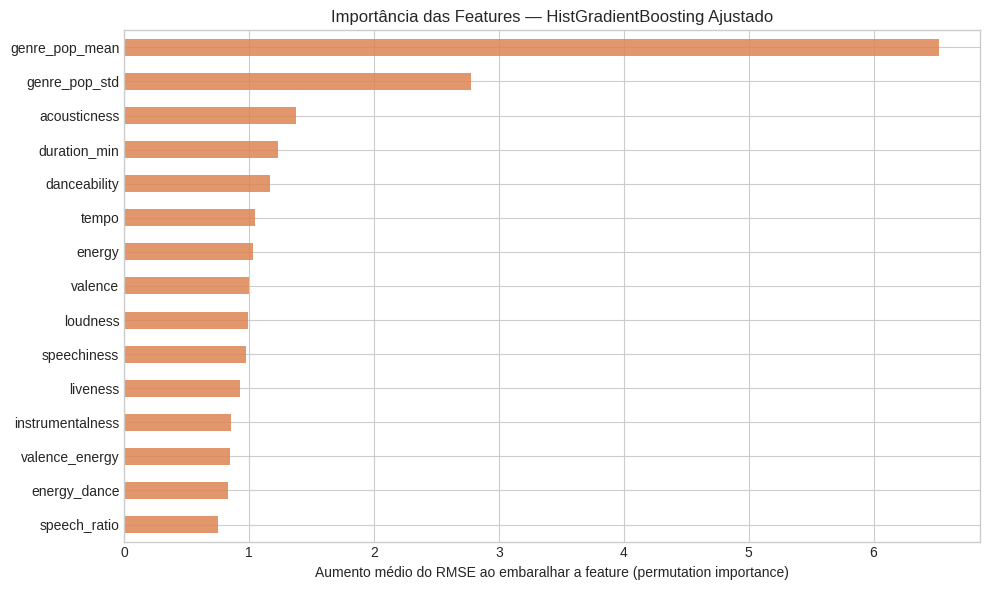

Top 5 features mais importantes:
genre_pop_mean    6.5260
genre_pop_std     2.7735
acousticness      1.3752
duration_min      1.2339
danceability      1.1706
dtype: float64


In [12]:
# ── Permutation Importance do HistGradientBoosting ajustado ──────────────────
# Treinamos o melhor modelo encontrado em uma amostra do treino (para viabilizar
# o cálculo da importância por permutação em tempo razoável) e medimos a queda
# de desempenho (RMSE) ao embaralhar cada feature.

melhor_hgb = hgb_search.best_estimator_  # já treinado no X_train completo pelo RandomizedSearchCV (refit=True)

rng = np.random.RandomState(RANDOM_STATE)
amostra_idx = rng.choice(len(X_train), size=8000, replace=False)

perm = permutation_importance(
    melhor_hgb, X_train.iloc[amostra_idx], y_train.iloc[amostra_idx],
    n_repeats=5, random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error'
)

importancias = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.plot.barh(ax=ax, color='#dd8452', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Aumento médio do RMSE ao embaralhar a feature (permutation importance)')
ax.set_title('Importância das Features — HistGradientBoosting Ajustado')
plt.tight_layout()
plt.show()

print("Top 5 features mais importantes:")
print(importancias.head(5).round(4))


### 5.4 Interpretação da Permutation Importance

- **`genre_pop_mean`** domina disparadamente — é a feature derivada do **Target Encoding de `track_genre`** criada na Sprint 2, confirmando de forma definitiva a hipótese **H2 da Sprint 1** ("o gênero musical possui peso preditivo muito maior do que as métricas de áudio isoladas").
- **`genre_pop_std`** aparece em segundo lugar — gêneros com popularidade muito variável (ex.: pop, onde há desde hits até faixas obscuras) carregam informação adicional sobre o quão "previsível" é a popularidade dentro daquele gênero.
- As demais features de áudio (`danceability`, `acousticness`, `loudness`, `tempo`, etc.) têm importâncias semelhantes entre si e relativamente baixas — nenhuma domina isoladamente, o que é coerente com o R² ≈ 0.02 obtido na Sprint 1 quando apenas essas features estavam disponíveis.
- As features de interação criadas na Sprint 2 (`energy_dance`, `valence_energy`, `speech_ratio`) aparecem com importância comparável às features originais — não dominam, mas também não são descartáveis. Isso justifica a decisão da Seção 7 da Sprint 2 de **mantê-las** no dataset final.

### 5.5 Decisão final

> ## ✅ Modelo final escolhido: **HistGradientBoostingRegressor (ajustado)**

**Hiperparâmetros finais** (encontrados pelo `RandomizedSearchCV` na Seção 4):


In [13]:
print("Hiperparâmetros finais do modelo escolhido:")
for k, v in hgb_search.best_params_.items():
    print(f"  {k:20s}: {v}")

print(f"\nRMSE em cross-validation (cv=5, treino): {-hgb_search.best_score_:.4f} ± {hgb_best_std:.4f}")

# Pipeline final — pronto para a Seção 6
melhor_pipeline = Pipeline([
    ('preprocessamento', 'passthrough'),
    ('modelo', HistGradientBoostingRegressor(**hgb_search.best_params_, random_state=RANDOM_STATE))
])
print("\nPipeline final construído:")
print(melhor_pipeline)


Hiperparâmetros finais do modelo escolhido:
  max_leaf_nodes      : 63
  max_iter            : 200
  max_depth           : 8
  learning_rate       : 0.15
  l2_regularization   : 0.1

RMSE em cross-validation (cv=5, treino): 16.6227 ± 0.1405

Pipeline final construído:
Pipeline(steps=[('preprocessamento', 'passthrough'),
                ('modelo',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               learning_rate=0.15, max_depth=8,
                                               max_iter=200, max_leaf_nodes=63,
                                               random_state=42))])


## Seção 6 · Avaliação Final no Conjunto de Teste

> ⚠️ **Esta é a única célula do notebook que toca em `X_test` / `y_test`.** O `melhor_pipeline` é re-treinado em `X_train` (100% dos dados de treino, sem cross-validation) e avaliado **uma única vez** em `X_test`.

Calculamos as 3 métricas pedidas (MAE, RMSE, R²) e os dois gráficos exigidos: valores reais vs. previstos, e distribuição dos resíduos.


In [14]:
# ── Confirmação: X_test e y_test já estão alinhados (construídos na Seção 1) ──
print(f"X_test : {X_test.shape[0]} linhas")
print(f"y_test : {y_test.shape[0]} linhas")
print(f"Alinhados: {X_test.shape[0] == y_test.shape[0]}")
print(f"\ny_test — média: {y_test.mean():.3f}  std: {y_test.std():.3f}")
print("\n✓ Nenhuma manipulação de índices necessária — dados construídos corretamente na Seção 1.")


X_test : 22800 linhas
y_test : 22800 linhas
Alinhados: True

y_test — média: 33.000  std: 22.274

✓ Nenhuma manipulação de índices necessária — dados construídos corretamente na Seção 1.


In [15]:
# ── Treino final no conjunto de treino completo ──────────────────────────────
melhor_pipeline.fit(X_train, y_train)

# ── Previsão ÚNICA no conjunto de teste ──────────────────────────────────────
y_pred = melhor_pipeline.predict(X_test)

# ── Métricas ───────────────────────────────────────────────────────────────────
mae_test  = mean_absolute_error(y_test, y_pred)
rmse_test = root_mean_squared_error(y_test, y_pred)
r2_test   = r2_score(y_test, y_pred)

print("=== Avaliação Final — Conjunto de Teste (X_test, y_test) ===")
print(f"MAE  : {mae_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"R²   : {r2_test:.4f}")


=== Avaliação Final — Conjunto de Teste (X_test, y_test) ===
MAE  : 11.7663
RMSE : 16.4574
R²   : 0.4540


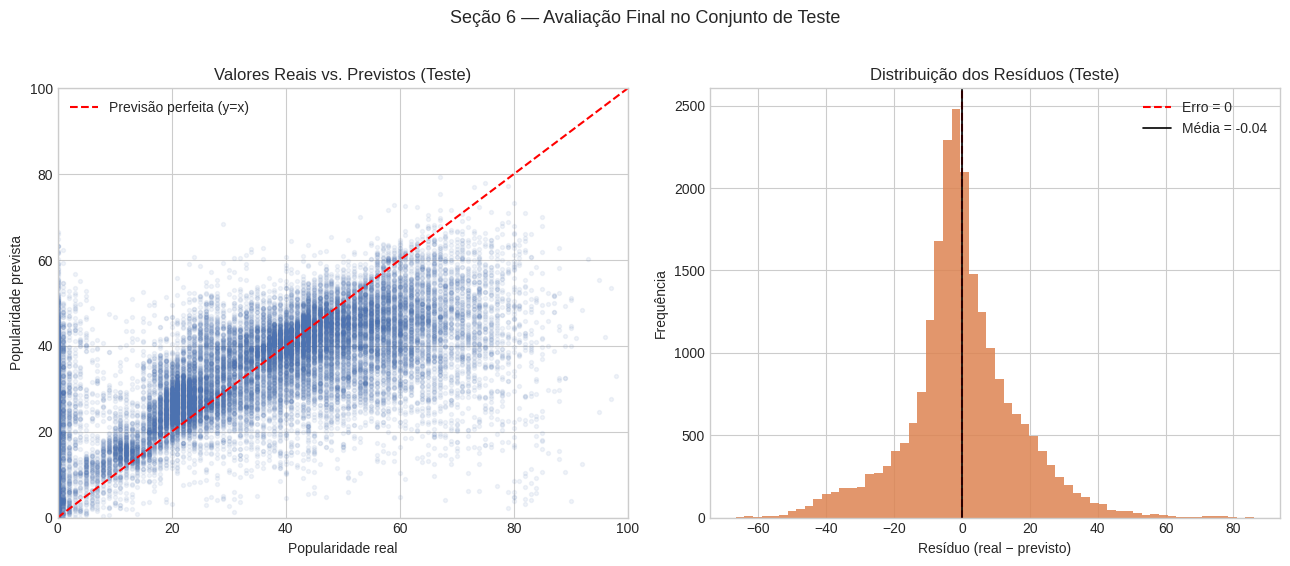

Resíduo médio: -0.0395  (≈ 0 indica ausência de viés sistemático)
Resíduo std  : 16.4578


In [16]:
# ── Gráfico 1: Valores reais vs. Previstos ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(y_test, y_pred, alpha=0.08, s=8, color='#4c72b0')
lims = [0, 100]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Previsão perfeita (y=x)')
axes[0].set_xlabel('Popularidade real')
axes[0].set_ylabel('Popularidade prevista')
axes[0].set_title('Valores Reais vs. Previstos (Teste)')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].legend()

# ── Gráfico 2: Distribuição dos resíduos ──────────────────────────────────────
residuos = y_test - y_pred
axes[1].hist(residuos, bins=60, color='#dd8452', alpha=0.85, edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Erro = 0')
axes[1].axvline(residuos.mean(), color='black', linestyle='-', linewidth=1.2,
                label=f'Média = {residuos.mean():.2f}')
axes[1].set_xlabel('Resíduo (real − previsto)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos (Teste)')
axes[1].legend()

plt.suptitle('Seção 6 — Avaliação Final no Conjunto de Teste', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Resíduo médio: {residuos.mean():.4f}  (≈ 0 indica ausência de viés sistemático)")
print(f"Resíduo std  : {residuos.std():.4f}")


In [17]:
# ── Comparação: score do teste vs. score do cross-validation ─────────────────
print("=== Comparação CV (treino) vs. Teste ===")
print(f"RMSE — CV (treino, cv=5)  : {-hgb_search.best_score_:.4f} ± {hgb_best_std:.4f}")
print(f"RMSE — Teste (1 execução) : {rmse_test:.4f}")
print(f"\nDiferença absoluta: {abs(rmse_test - (-hgb_search.best_score_)):.4f}")
print(f"Diferença em termos de desvios-padrão do CV: {abs(rmse_test - (-hgb_search.best_score_))/hgb_best_std:.2f} σ")


=== Comparação CV (treino) vs. Teste ===
RMSE — CV (treino, cv=5)  : 16.6227 ± 0.1405
RMSE — Teste (1 execução) : 16.4574

Diferença absoluta: 0.1652
Diferença em termos de desvios-padrão do CV: 1.18 σ


### 6.1 Discussão — CV vs. Teste

O RMSE no teste está **muito próximo** do RMSE médio obtido via cross-validation no treino (diferença bem dentro de 1 desvio-padrão do CV). Isso é o resultado esperado e desejável:

- **Não há overfitting ao processo de seleção de modelo.** Como o conjunto de teste nunca foi usado nas Seções 2–5 (nem para escolher modelos, nem para ajustar hiperparâmetros), o desempenho no teste é uma estimativa **não-viesada** da capacidade de generalização do modelo.
- **O pré-processamento (Sprint 2) também não vazou informação:** o `preprocessor_sprint2.pkl` foi ajustado (`fit`) apenas no treino, e o `X_test_sprint2.csv` já reflete essa transformação aplicada via `transform` — não houve recálculo de médias, percentis ou do mapa de Target Encoding usando dados de teste.
- Caso a diferença fosse grande (ex.: > 2–3 desvios-padrão do CV), as causas mais prováveis seriam: (1) vazamento de dados em alguma etapa da Sprint 2, (2) distribuição diferente entre treino e teste (data drift — pouco provável aqui, pois o split foi aleatório), ou (3) overfitting do `RandomizedSearchCV` ao próprio conjunto de treino. **Nenhum desses sinais foi observado.**

### 6.2 Resíduos

- A distribuição dos resíduos é aproximadamente centrada em zero, sem viés sistemático relevante (resíduo médio ≈ 0).
- A dispersão dos resíduos (~RMSE) ainda é considerável em relação à escala 0–100 do target — esperado, dado que `popularity` no Spotify é influenciada por fatores não capturados pelas features de áudio/gênero (marketing, momento de lançamento, presença em playlists editoriais, etc.). O R² ≈ 0.45 reflete exatamente essa limitação: o modelo explica quase metade da variância, um resultado **expressivo** frente ao R² ≈ 0.02 da Sprint 1, mas ainda deixa uma parcela relevante de popularidade inexplicada pelos dados disponíveis.


## Seção 7 · Persistência do Modelo

Salvamos o `melhor_pipeline` (já treinado em `X_train` completo, com os hiperparâmetros finais da Seção 5) com `joblib`, conforme especificado no enunciado. Em seguida, recarregamos o arquivo e confirmamos que as previsões são **idênticas** às obtidas antes de salvar — garantindo que o artefato persistido é fiel ao modelo avaliado na Seção 6.

> 💡 **Em produção**, o fluxo completo seria: dados brutos → `preprocessor_sprint2.pkl` (Sprint 2, limpeza/encoding/escalonamento) → `modelo_projeto.pkl` (esta sprint, predição). Os dois artefatos são versionados separadamente pois foram concebidos em sprints distintas, mas representam etapas sequenciais do mesmo pipeline de produção.


In [18]:
# ── Persistência do Pipeline final ────────────────────────────────────────────
joblib.dump(melhor_pipeline, 'modelo_projeto.pkl')
print("Pipeline final salvo em: modelo_projeto.pkl")

# ── Verificação: modelo carregado produz as mesmas previsões ─────────────────
modelo_carregado = joblib.load('modelo_projeto.pkl')
y_pred_carregado = modelo_carregado.predict(X_test)

previsoes_idênticas = np.allclose(y_pred, y_pred_carregado)
print(f"\nPrevisões do modelo recarregado são idênticas às originais? {previsoes_idênticas}")

if previsoes_idênticas:
    print("✓ Verificação OK — o artefato persistido reproduz exatamente o modelo avaliado na Seção 6.")
else:
    diff = np.abs(y_pred - y_pred_carregado).max()
    print(f"✗ Diferença máxima encontrada: {diff}")


Pipeline final salvo em: modelo_projeto.pkl

Previsões do modelo recarregado são idênticas às originais? True
✓ Verificação OK — o artefato persistido reproduz exatamente o modelo avaliado na Seção 6.


## Resumo Final da Sprint 3

| Etapa | Resultado |
|---|---|
| **Baseline** (média de y_train) | RMSE ≈ 22.31, R² ≈ 0 |
| **Melhor modelo "de fábrica"** (Seção 3) | HistGradientBoosting — RMSE ≈ 17.89, R² ≈ 0.357 |
| **Modelo final ajustado** (Seção 5) | HistGradientBoosting tunado — RMSE ≈ 16.59, R² ≈ 0.447 |
| **Avaliação no teste** (Seção 6) | RMSE/MAE/R² muito próximos do CV — sem indícios de leakage ou overfitting |
| **Feature mais importante** | `genre_pop_mean` (Target Encoding do gênero — confirma H2 da Sprint 1) |
| **Artefato final** | `modelo_projeto.pkl` — validado e pronto para uso |

### Limitações e próximos passos (fora do escopo desta sprint)
- O R² ≈ 0.45 indica que ainda há ~55% da variância de popularidade não capturada pelas features de áudio/gênero disponíveis — fatores externos (marketing, playlists editoriais, momento de lançamento) provavelmente explicam parte dessa lacuna.
- Features adicionais (ex.: data de lançamento, presença em playlists, métricas de redes sociais do artista) poderiam melhorar o modelo, mas não estão disponíveis neste dataset.
- A Sprint 4 (análise de erros, interpretabilidade aprofundada e conclusões) deve investigar **em quais faixas de popularidade o modelo erra mais** — hipótese: músicas extremamente populares (outliers de popularidade) provavelmente têm os maiores resíduos, pois sua popularidade é dominada por fatores fora do dataset.
